# SHAP Feature Importance via LOSO Cross-Validation

Explainer used per model:
- RF: `shap.TreeExplainer` on `pipeline['rf']` with transformed data
- HGB: `shap.TreeExplainer` on raw data (HGB handles scaling internally)
- LR:`shap.LinearExplainer` on log scaled data
- SVM: `shap.PermutationExplainer` on full pipeline

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score
from pathlib import Path

shap.initjs()

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

PALETTE = {"SVM": "#7F77DD", "HGB": "#1D9E75", "LR": "#BA7517", "RF": "#B07FC8"}
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


## Data Loading

In [2]:
BASE = Path("../data")

train_a = pd.read_csv(BASE / "train_a.csv")
test_a  = pd.read_csv(BASE / "test_a.csv")
df_a = pd.concat([train_a, test_a], ignore_index=True)
df_a["subject"] = df_a["name"].str.extract(r"(S\d+)")

# Dataset B (NaN-row dropped)
train_b = pd.read_csv(BASE / "train_b.csv")
test_b  = pd.read_csv(BASE / "test_b.csv")
df_b = pd.concat([train_b, test_b], ignore_index=True)
df_b["subject"] = df_b["name"].str.extract(r"(S\d+)")

feat_cols = [c for c in df_a.columns if c not in ("name", "subject", "status")]
print(f"Dataset A: {len(df_a)} recordings, {df_a['subject'].nunique()} subjects, {len(feat_cols)} features")
print(f"Dataset B: {len(df_b)} recordings, {df_b['subject'].nunique()} subjects")

def prep(df):
    X = df[feat_cols].values.astype(float)
    y = df["status"].values.astype(int)
    g = LabelEncoder().fit_transform(df["subject"])
    return X, y, g

X_a, y_a, g_a = prep(df_a)
X_b, y_b, g_b = prep(df_b)

Dataset A: 195 recordings, 32 subjects, 22 features
Dataset B: 187 recordings, 32 subjects


In [3]:
from sklearn.decomposition import PCA

def flag_outliers(df, feat_cols):
    """Flag outlier recordings using IQR (≥3 features), Z-score (|z|>3), and PCA Mahalanobis (97.5th pct)."""
    def iqr_flag(series):
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)
    iqr_outlier = pd.DataFrame({f: iqr_flag(df[f]) for f in feat_cols}).sum(axis=1) >= 3

    X_scaled       = StandardScaler().fit_transform(df[feat_cols])
    zscore_outlier = (np.abs(X_scaled) > 3).any(axis=1)

    X_pca = PCA(n_components=2).fit_transform(X_scaled)
    def mahal_dist(X):
        mu      = X.mean(axis=0)
        inv_cov = np.linalg.pinv(np.cov(X.T))
        diff    = X - mu
        return np.sqrt(np.einsum("ij,jk,ik->i", diff, inv_cov, diff))
    mahal = np.zeros(len(df))
    for g in df["status"].unique():
        mask = (df["status"] == g).values
        mahal[mask] = mahal_dist(X_pca[mask])
    pca_outlier = mahal > np.percentile(mahal, 97.5)

    return iqr_outlier.values | zscore_outlier | pca_outlier

clean_a = df_a[~flag_outliers(df_a, feat_cols)].reset_index(drop=True)
clean_b = df_b[~flag_outliers(df_b, feat_cols)].reset_index(drop=True)

X_clean_a, y_clean_a, g_clean_a = prep(clean_a)
X_clean_b, y_clean_b, g_clean_b = prep(clean_b)

print(f"Dataset A: {len(df_a)} -> {len(clean_a)} recordings ({len(df_a)-len(clean_a)} outliers removed)")
print(f"Dataset B: {len(df_b)} -> {len(clean_b)} recordings ({len(df_b)-len(clean_b)} outliers removed)")

Dataset A: 195 -> 172 recordings (23 outliers removed)
Dataset B: 187 -> 165 recordings (22 outliers removed)


## LogTransformer (identical to loso_evaluation.ipynb)

In [4]:
SKEWED_FEATURES = [
    "MDVP:Fo(Hz)", "MDVP:Fhi(Hz)", "MDVP:Flo(Hz)",
    "MDVP:Jitter(%)", "MDVP:Jitter(Abs)", "MDVP:RAP", "MDVP:PPQ", "Jitter:DDP",
    "MDVP:Shimmer", "MDVP:Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5",
    "MDVP:APQ", "Shimmer:DDA", "NHR", "PPE", "spread1", "D2",
]


class LogTransformer(BaseEstimator, TransformerMixin):
    """Log-transform skewed features; fit on training fold only."""

    def __init__(self, skewed_cols, all_cols):
        self.skewed_cols = skewed_cols
        self.all_cols    = all_cols

    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols)
        self.mins_    = {c: df[c].min()             for c in self.skewed_cols}
        self.use_log_ = {c: bool((df[c] > 0).all()) for c in self.skewed_cols}
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols).copy()
        for c in self.skewed_cols:
            if self.use_log_[c]:
                df[c] = np.log(df[c])
            else:
                df[c] = np.log1p(df[c] - self.mins_[c])
        return df.values


def make_preprocessor(feat_cols):
    """Log + StandardScaler pipeline (all steps except the classifier)."""
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    return Pipeline([
        ("log", LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ("sc",  StandardScaler()),
    ])

## LOSO SHAP Core Function

For each outer fold:
1. Fit the model on training subjects (with inner GroupKFold hyperparameter search)
2. Transform held-out recordings through the preprocessing steps
3. Compute SHAP values for the held-out recordings using that fold's fitted model
4. Store SHAP values + original feature values for aggregation

In [5]:
def _extract_shap(clf, X_tr_t, X_te_t, X_te_orig, feat_cols, model_type):
    if model_type == "rf":
        exp = shap.TreeExplainer(
            clf, data=X_tr_t, feature_perturbation="interventional"
        )
        sv = exp.shap_values(X_te_t)
        # Newer shap: (n_samples, n_features, n_classes)
        if isinstance(sv, np.ndarray) and sv.ndim == 3:
            return sv[:, :, 1]
        return sv[1]  # older shap: list [class0, class1]

    elif model_type == "hgb":
        exp = shap.TreeExplainer(clf)
        sv = exp.shap_values(X_te_orig)  # HGB uses raw (unscaled) features
        if isinstance(sv, np.ndarray) and sv.ndim == 2:
            return sv
        if isinstance(sv, np.ndarray) and sv.ndim == 3:
            return sv[:, :, 1]
        return sv[1]

    elif model_type == "lr":
        exp = shap.LinearExplainer(clf, X_tr_t)
        sv = exp.shap_values(X_te_t)
        if isinstance(sv, np.ndarray) and sv.ndim == 2:
            return sv
        return sv[1]

    elif model_type == "svm":
        # PermutationExplainer: slower but model-agnostic
        # Uses predict_proba[:, 1] (prob of PD) as target
        def f(x): return clf.decision_function(x)
        bg = shap.sample(X_tr_t, 50, random_state=42)
        exp = shap.PermutationExplainer(f, bg)
        sv = exp(X_te_t)
        return sv.values

    raise ValueError(f"Unknown model_type: {model_type}")


def loso_shap(pipe_fn, grid, X, y, groups, feat_cols, model_type,
              inner_k=4, verbose=True):
    logo = LeaveOneGroupOut()
    all_shap, all_X, all_y, all_yhat, row_order, ba_scores = [], [], [], [], [], []

    for fold_i, (tr, te) in enumerate(logo.split(X, y, groups)):
        g_tr = groups[tr]
        n_inner = min(inner_k, len(np.unique(g_tr)))

        gs = GridSearchCV(
            pipe_fn(), grid,
            cv=GroupKFold(n_inner),
            scoring="balanced_accuracy", n_jobs=-1, refit=True
        )
        gs.fit(X[tr], y[tr], groups=g_tr)
        pipe = gs.best_estimator_

        # Transform features (all steps except classifier)
        if model_type in ("rf", "lr", "svm"):
            pre   = pipe[:-1]
            clf   = pipe[-1]
            X_tr_t = pre.transform(X[tr])
            X_te_t = pre.transform(X[te])
        else:  # hgb: no separate transform needed
            pre   = None
            clf   = pipe["hgb"]
            X_tr_t = X[tr]
            X_te_t = X[te]

        shap_fold = _extract_shap(clf, X_tr_t, X_te_t, X[te], feat_cols, model_type)
        y_pred    = gs.predict(X[te])
        ba        = balanced_accuracy_score(y[te], y_pred)

        all_shap.append(shap_fold)
        all_X.append(X[te])
        all_y.append(y[te])
        all_yhat.append(y_pred)
        row_order.append(te)
        ba_scores.append(ba)

        subj_type = "Healthy" if y[te][0] == 0 else "PD"
        correct   = "✓" if y_pred[0] == y[te][0] else "✗"
        if verbose:
            print(f"  fold {fold_i+1:2d} ({subj_type:7s}) BA={ba:.2f} {correct}  "
                  f"best={gs.best_params_}")

    return (np.vstack(all_shap), np.vstack(all_X),
            np.concatenate(all_y), np.concatenate(all_yhat),
            np.concatenate(row_order), ba_scores)

## Model Pipeline Factories (matching loso_evaluation.ipynb)

In [6]:
# RF 
def make_rf_pipe():
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    return Pipeline([
        ("log", LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ("sc",  StandardScaler()),
        ("rf",  RandomForestClassifier(class_weight="balanced", random_state=42)),
    ])

RF_GRID = {
    "rf__n_estimators":     [100, 200],
    "rf__max_depth":        [None, 10, 20],
    "rf__min_samples_leaf": [1, 5],
}

# HGB
def make_hgb_pipe():
    return Pipeline([
        ("hgb", HistGradientBoostingClassifier(
            class_weight="balanced", random_state=42,
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        )),
    ])

HGB_GRID = {
    "hgb__learning_rate":     [0.05, 0.1],
    "hgb__max_iter":          [100, 200],
    "hgb__max_leaf_nodes":    [5, 15, 31],
    "hgb__l2_regularization": [0.0, 0.1, 1.0],
    "hgb__min_samples_leaf":  [10, 20],
}

# LR
def make_lr_pipe():
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    return Pipeline([
        ("log", LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ("sc",  StandardScaler()),
        ("lr",  LogisticRegression(penalty="l1", solver="liblinear",
                                   class_weight="balanced", random_state=42,
                                   max_iter=1000)),
    ])

LR_GRID = {"lr__C": np.logspace(-3, 3, 10)}

# SVM
def make_svm_pipe():
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    return Pipeline([
        ("log", LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ("sc",  StandardScaler()),
        ("svm", SVC(kernel="rbf", class_weight="balanced",
                    random_state=42, probability=False)),
    ])

SVM_GRID = {"svm__C": [0.1, 1, 10, 100], "svm__gamma": ["scale", "auto"]}

print("Pipeline factories defined.")

Pipeline factories defined.


## RF: LOSO SHAP (Dataset A, All Features)

In [7]:
import time
_cache = Path("outputs/shap_rf_matrix.csv")
if _cache.exists():
    print("Loading RF SHAP from cache (delete outputs/shap_rf_matrix.csv to re-run).")
    rf_shap      = pd.read_csv(_cache).values
    _imp          = pd.read_csv("outputs/shap_rf_importance.csv")
    rf_importance = _imp.set_index(_imp.columns[0])[_imp.columns[1]].sort_values(ascending=False)
    rf_X          = X_a
    rf_y          = y_a
    _yhat_f       = Path("outputs/shap_rf_yhat.csv")
    rf_yhat       = pd.read_csv(_yhat_f)["yhat"].values if _yhat_f.exists() else np.full_like(y_a, -1)
    rf_ba         = []
    print(f"  SHAP matrix: {rf_shap.shape}")
    print("\nTop 10 features by mean |SHAP|:")
    print(rf_importance.head(10).to_string())
else:
    print("Running RF LOSO SHAP on Dataset A…")
    t0 = time.time()
    rf_shap, rf_X, rf_y, rf_yhat, rf_order, rf_ba = loso_shap(
        make_rf_pipe, RF_GRID, X_a, y_a, g_a, feat_cols, model_type="rf"
    )
    print(f"\nDone in {time.time()-t0:.1f}s")
    print(f"Mean LOSO BA: {np.mean(rf_ba):.3f} ± {np.std(rf_ba):.3f}")
    print(f"SHAP matrix: {rf_shap.shape}  (should be 195 × 22)")
    rf_importance = pd.Series(np.abs(rf_shap).mean(axis=0), index=feat_cols).sort_values(ascending=False)
    print("\nTop 10 features by mean |SHAP|:")
    print(rf_importance.head(10).to_string())

Loading RF SHAP from cache (delete outputs/shap_rf_matrix.csv to re-run).
  SHAP matrix: (195, 22)

Top 10 features by mean |SHAP|:
feature
PPE             0.061121
spread1         0.048627
spread2         0.033417
MDVP:Fhi(Hz)    0.024417
MDVP:APQ        0.023786
Shimmer:APQ5    0.021685
MDVP:Fo(Hz)     0.020004
MDVP:Shimmer    0.015164
MDVP:RAP        0.014925
D2              0.014054


## HGB: LOSO SHAP (Dataset A, All Features)

In [8]:
_cache = Path("outputs/shap_hgb_matrix.csv")
if _cache.exists():
    print("Loading HGB SHAP from cache (delete outputs/shap_hgb_matrix.csv to re-run).")
    hgb_shap      = pd.read_csv(_cache).values
    _imp           = pd.read_csv("outputs/shap_hgb_importance.csv")
    hgb_importance = _imp.set_index(_imp.columns[0])[_imp.columns[1]].sort_values(ascending=False)
    hgb_X          = X_a
    hgb_y          = y_a
    _yhat_f        = Path("outputs/shap_hgb_yhat.csv")
    hgb_yhat       = pd.read_csv(_yhat_f)["yhat"].values if _yhat_f.exists() else np.full_like(y_a, -1)
    hgb_ba         = []
    print(f"  SHAP matrix: {hgb_shap.shape}")
    print("\nTop 10 features by mean |SHAP|:")
    print(hgb_importance.head(10).to_string())
else:
    print("Running HGB LOSO SHAP on Dataset A…")
    t0 = time.time()
    hgb_shap, hgb_X, hgb_y, hgb_yhat, hgb_order, hgb_ba = loso_shap(
        make_hgb_pipe, HGB_GRID, X_a, y_a, g_a, feat_cols, model_type="hgb"
    )
    print(f"\nDone in {time.time()-t0:.1f}s")
    print(f"Mean LOSO BA: {np.mean(hgb_ba):.3f} ± {np.std(hgb_ba):.3f}")
    hgb_importance = pd.Series(np.abs(hgb_shap).mean(axis=0), index=feat_cols).sort_values(ascending=False)
    print("\nTop 10 features by mean |SHAP|:")
    print(hgb_importance.head(10).to_string())

Loading HGB SHAP from cache (delete outputs/shap_hgb_matrix.csv to re-run).
  SHAP matrix: (195, 22)

Top 10 features by mean |SHAP|:
feature
spread2         0.979272
MDVP:Fo(Hz)     0.571196
PPE             0.550019
MDVP:Fhi(Hz)    0.508651
spread1         0.470843
DFA             0.421320
Shimmer:APQ5    0.369447
D2              0.344284
NHR             0.326458
MDVP:RAP        0.249437


## LR: LOSO SHAP (Dataset A, All Features)

In [9]:
_cache = Path("outputs/shap_lr_matrix.csv")
if _cache.exists():
    print("Loading LR SHAP from cache (delete outputs/shap_lr_matrix.csv to re-run).")
    lr_shap      = pd.read_csv(_cache).values
    _imp          = pd.read_csv("outputs/shap_lr_importance.csv")
    lr_importance = _imp.set_index(_imp.columns[0])[_imp.columns[1]].sort_values(ascending=False)
    lr_X          = X_a
    lr_y          = y_a
    _yhat_f       = Path("outputs/shap_lr_yhat.csv")
    lr_yhat       = pd.read_csv(_yhat_f)["yhat"].values if _yhat_f.exists() else np.full_like(y_a, -1)
    lr_ba         = []
    print(f"  SHAP matrix: {lr_shap.shape}")
    print("\nTop 10 features by mean |SHAP|:")
    print(lr_importance.head(10).to_string())
else:
    print("Running LR LOSO SHAP on Dataset A…")
    t0 = time.time()
    lr_shap, lr_X, lr_y, lr_yhat, lr_order, lr_ba = loso_shap(
        make_lr_pipe, LR_GRID, X_a, y_a, g_a, feat_cols, model_type="lr"
    )
    print(f"\nDone in {time.time()-t0:.1f}s")
    print(f"Mean LOSO BA: {np.mean(lr_ba):.3f} ± {np.std(lr_ba):.3f}")
    lr_importance = pd.Series(np.abs(lr_shap).mean(axis=0), index=feat_cols).sort_values(ascending=False)
    print("\nTop 10 features by mean |SHAP|:")
    print(lr_importance.head(10).to_string())

Loading LR SHAP from cache (delete outputs/shap_lr_matrix.csv to re-run).
  SHAP matrix: (195, 22)

Top 10 features by mean |SHAP|:
feature
spread1         0.407446
PPE             0.124634
spread2         0.055334
MDVP:APQ        0.038930
D2              0.019853
DFA             0.007908
MDVP:Fhi(Hz)    0.001174
MDVP:Fo(Hz)     0.000000
RPDE            0.000000
HNR             0.000000


## SVM: LOSO SHAP

In [10]:
_cache = Path("outputs/shap_svm_matrix.csv")
if _cache.exists():
    print("Loading SVM SHAP from cache (delete outputs/shap_svm_matrix.csv to re-run).")
    svm_shap      = pd.read_csv(_cache).values
    _imp           = pd.read_csv("outputs/shap_svm_importance.csv")
    svm_importance = _imp.set_index(_imp.columns[0])[_imp.columns[1]].sort_values(ascending=False)
    svm_X          = X_a
    svm_y          = y_a
    _yhat_f        = Path("outputs/shap_svm_yhat.csv")
    svm_yhat       = pd.read_csv(_yhat_f)["yhat"].values if _yhat_f.exists() else np.full_like(y_a, -1)
    svm_ba         = []
    print(f"  SHAP matrix: {svm_shap.shape}")
    print("\nTop 10 features by mean |SHAP|:")
    print(svm_importance.head(10).to_string())
else:
    print("Running SVM LOSO SHAP on Dataset A (~5 min)…")
    t0 = time.time()
    svm_shap, svm_X, svm_y, svm_yhat, svm_order, svm_ba = loso_shap(
        make_svm_pipe, SVM_GRID, X_a, y_a, g_a, feat_cols, model_type="svm",
        inner_k=4, verbose=True,
    )
    print(f"\nDone in {time.time()-t0:.1f}s")
    svm_importance = pd.Series(np.abs(svm_shap).mean(axis=0), index=feat_cols).sort_values(ascending=False)
    print(svm_importance.head(10).to_string())

Loading SVM SHAP from cache (delete outputs/shap_svm_matrix.csv to re-run).
  SHAP matrix: (195, 22)

Top 10 features by mean |SHAP|:
feature
PPE                 0.203481
spread2             0.177404
spread1             0.153399
MDVP:RAP            0.150955
DFA                 0.135274
MDVP:PPQ            0.127944
MDVP:Jitter(%)      0.110802
Jitter:DDP          0.110791
MDVP:Jitter(Abs)    0.103579
D2                  0.101079


## Cross Model Feature Importance Comparison

Bar chart of mean |SHAP| for each model, top 15 features.
Features are sorted by RF mean |SHAP| so ordering is consistent across models.

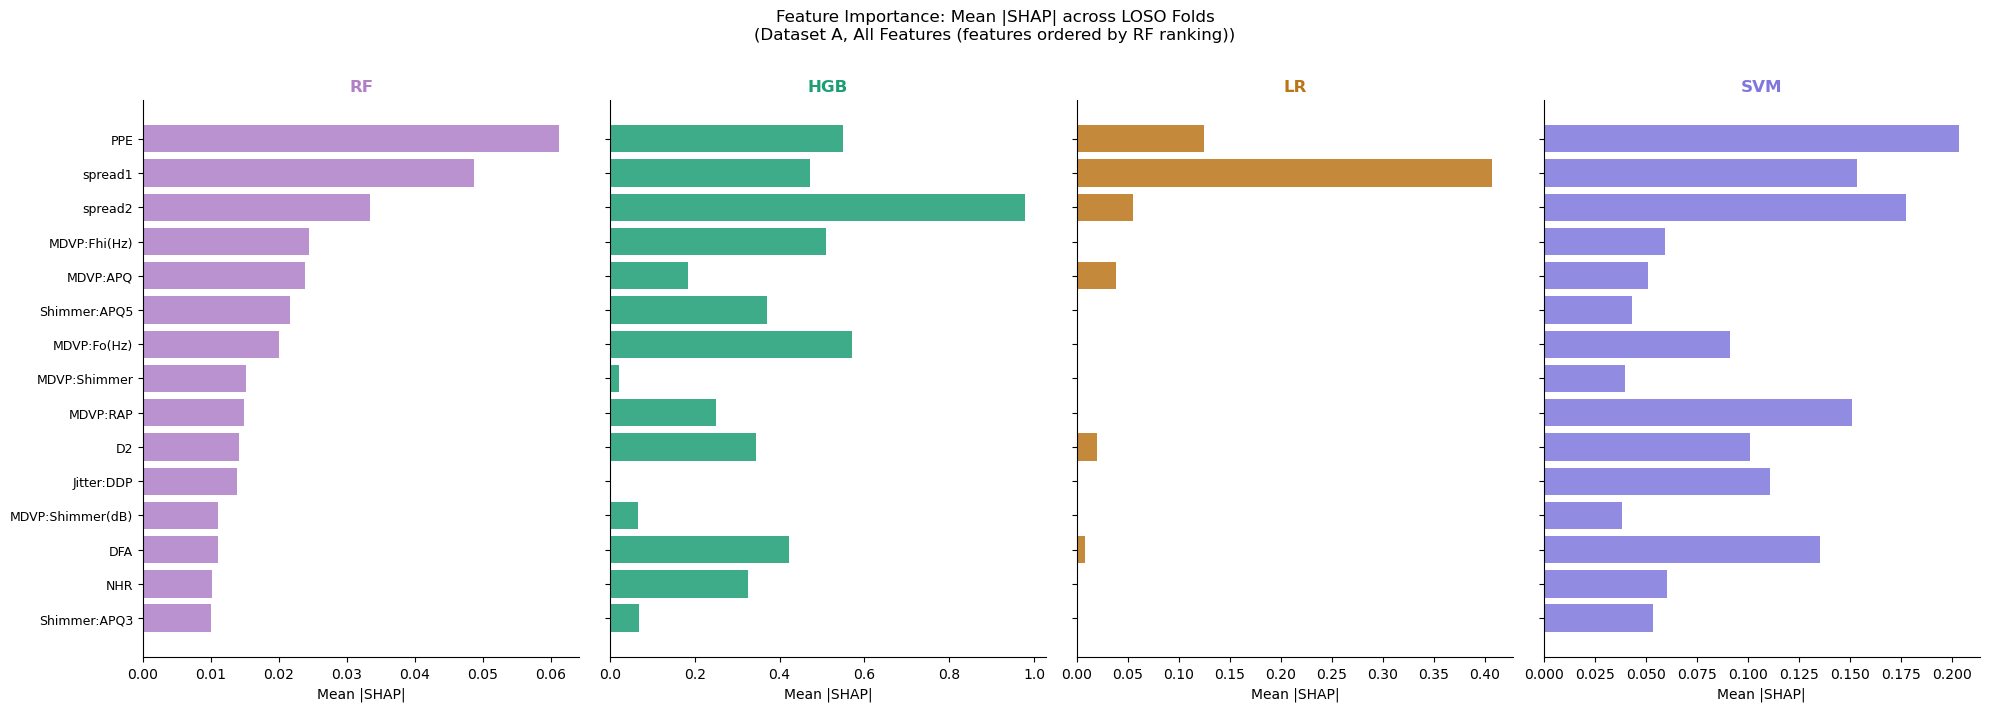

Saved → plots/shap_importance_comparison.png


In [11]:
# Collect all importances
importances = {
    "RF":  rf_importance,
    "HGB": hgb_importance,
    "LR":  lr_importance,
}
# Add SVM if computed:
try:
    importances["SVM"] = svm_importance
except NameError:
    pass

# Use RF ordering as canonical
feat_order = rf_importance.index.tolist()[:15]

fig, axes = plt.subplots(1, len(importances), figsize=(5 * len(importances), 7), sharey=True)
if len(importances) == 1:
    axes = [axes]

for ax, (model, imp) in zip(axes, importances.items()):
    vals = [imp.get(f, 0) for f in feat_order]
    colors = [PALETTE[model]] * len(feat_order)
    ax.barh(range(len(feat_order)), vals[::-1], color=PALETTE[model], alpha=0.85)
    ax.set_yticks(range(len(feat_order)))
    ax.set_yticklabels(feat_order[::-1], fontsize=9)
    ax.set_xlabel("Mean |SHAP|", fontsize=10)
    ax.set_title(f"{model}", fontsize=12, color=PALETTE[model], fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Feature Importance: Mean |SHAP| across LOSO Folds\n"
             "(Dataset A, All Features (features ordered by RF ranking))",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_importance_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {PLOTS_DIR / 'shap_importance_comparison.png'}")

## RF Beeswarm Plot

Shows both the **magnitude** (x-axis) and **direction** (dot colour = original feature value)
of each feature's contribution to the PD prediction, across all 195 recordings.

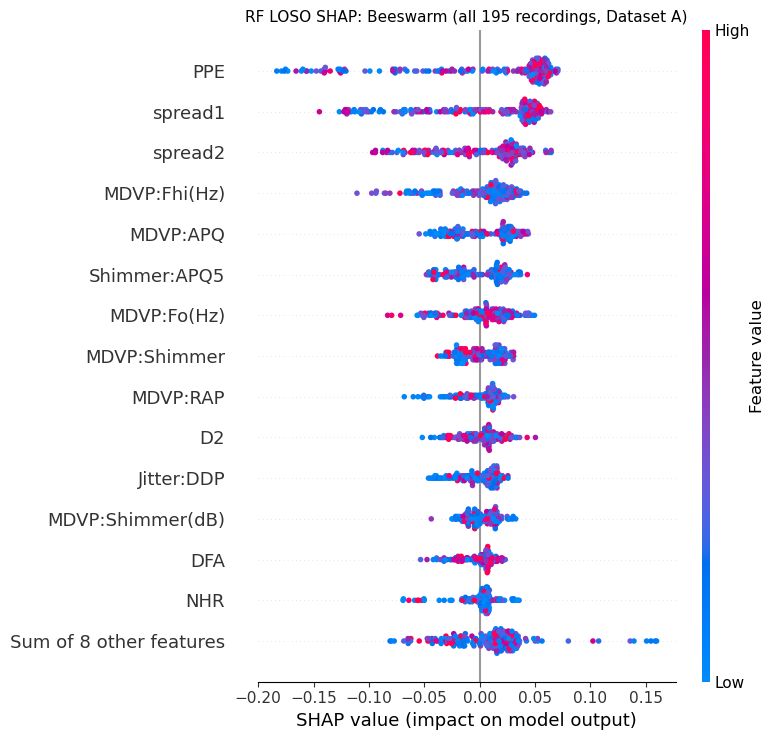

Saved -> plots/shap_rf_beeswarm.png


In [12]:
# Build SHAP Explanation object using original feature values for colour
rf_exp = shap.Explanation(
    values=rf_shap,
    base_values=np.zeros(len(rf_shap)),   # placeholder; beeswarm doesn't need exact base
    data=rf_X,                             # original (untransformed) for colouring
    feature_names=feat_cols,
)

fig, ax = plt.subplots(figsize=(9, 8))
shap.plots.beeswarm(rf_exp, max_display=15, show=False)
plt.title("RF LOSO SHAP: Beeswarm (all 195 recordings, Dataset A)",
        #   "Positive SHAP → pushes toward PD prediction; colour = original feature value",
          fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_rf_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'shap_rf_beeswarm.png'}")

## LR Beeswarm

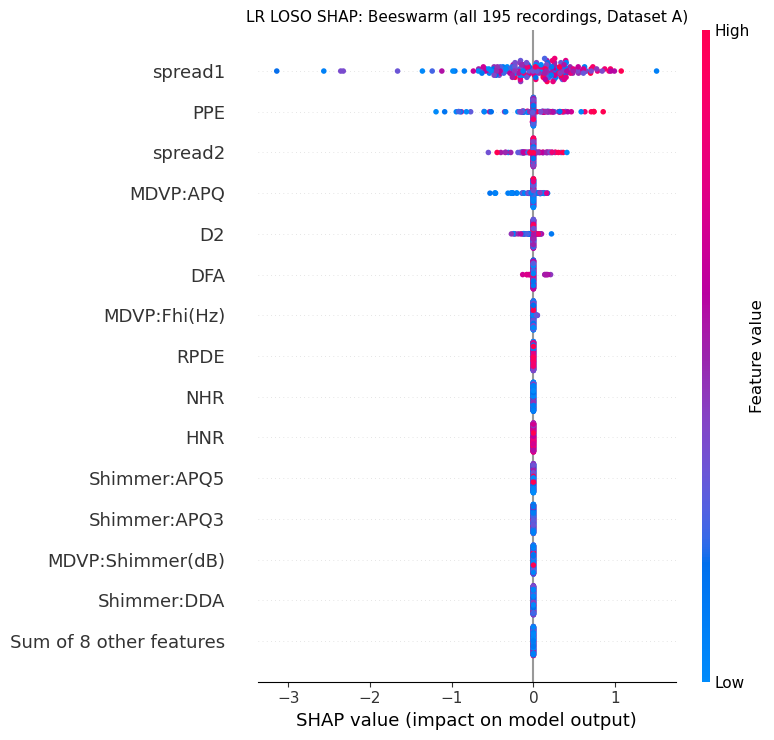

Saved -> plots/shap_lr_beeswarm.png


In [13]:
lr_exp = shap.Explanation(
    values=lr_shap,
    base_values=np.zeros(len(lr_shap)),
    data=lr_X,
    feature_names=feat_cols,
)

fig, ax = plt.subplots(figsize=(9, 8))
shap.plots.beeswarm(lr_exp, max_display=15, show=False)
plt.title("LR LOSO SHAP: Beeswarm (all 195 recordings, Dataset A)",
        #   "Values in log+scaled feature space; colour = original feature value",
          fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_lr_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'shap_lr_beeswarm.png'}")

## HGB Beeswarm

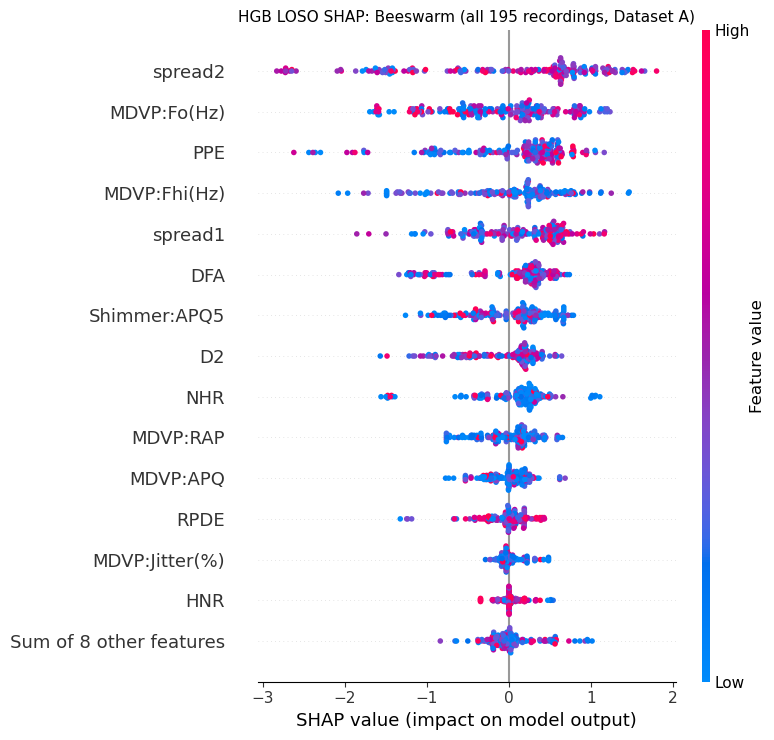

Saved -> plots/shap_hgb_beeswarm.png


In [14]:
hgb_exp = shap.Explanation(
    values=hgb_shap,
    base_values=np.zeros(len(hgb_shap)),
    data=hgb_X,
    feature_names=feat_cols,
)

fig, ax = plt.subplots(figsize=(9, 8))
shap.plots.beeswarm(hgb_exp, max_display=15, show=False)
plt.title("HGB LOSO SHAP: Beeswarm (all 195 recordings, Dataset A)",
        #   "Positive SHAP → pushes toward PD prediction; colour = original feature value",
          fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_hgb_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'shap_hgb_beeswarm.png'}")

## SVM Beeswarm

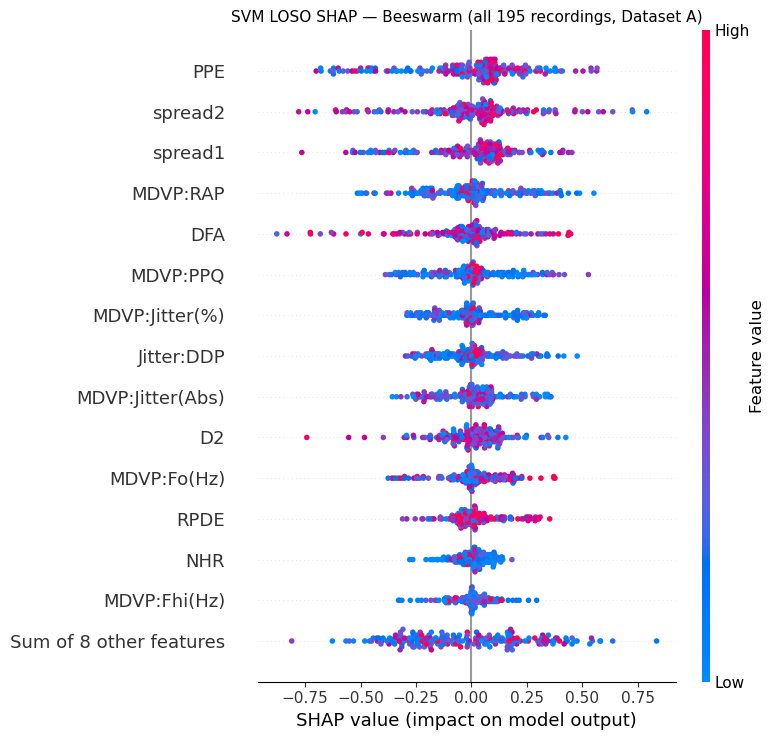

In [15]:
svm_exp = shap.Explanation(
    values=svm_shap,
    base_values=np.zeros(len(svm_shap)),
    data=svm_X,
    feature_names=feat_cols,
)

fig, ax = plt.subplots(figsize=(9, 8))
shap.plots.beeswarm(svm_exp, max_display=15, show=False)
plt.title("SVM LOSO SHAP — Beeswarm (all 195 recordings, Dataset A)",
        #   "PermutationExplainer values on log+scaled features; colour = original feature value",
          fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_svm_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

## Per-Subject Waterfall: Misclassified Cases

For each subject misclassified by RF, plot a SHAP waterfall to show which features
drove the wrong prediction. Useful for qualitative error analysis.

RF misclassified 195, 195 recordings
  True PD misclassified as Healthy: 0
  True Healthy misclassified as PD: 0

Indices of misclassified recordings: [0 1 2 3 4 5 6 7 8 9]...


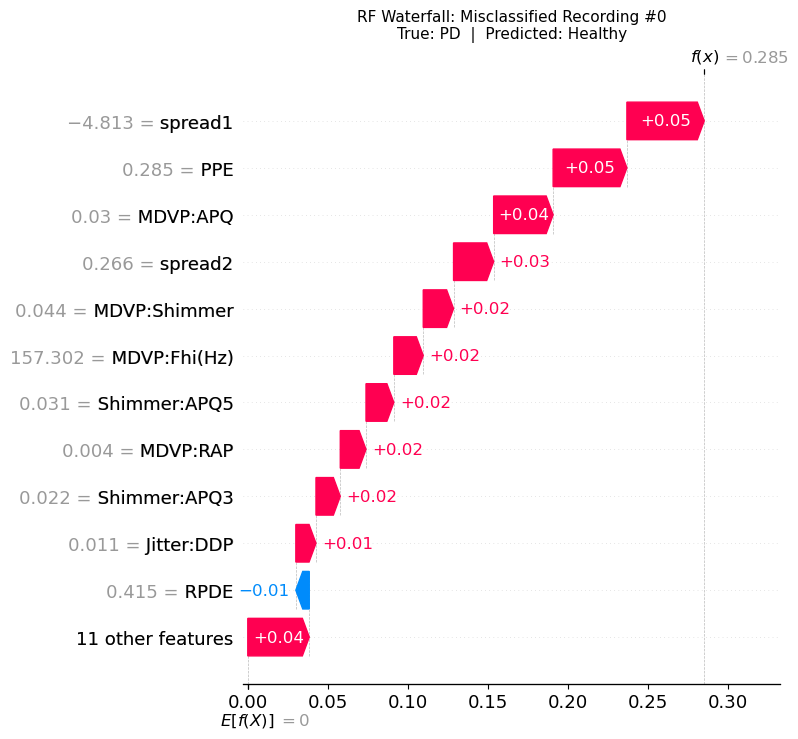

Saved -> plots/shap_rf_waterfall_misclassified.png


In [16]:
# Find misclassified subjects (RF)
misclassified_mask = rf_y != rf_yhat
print(f"RF misclassified {misclassified_mask.sum()}, {len(rf_y)} recordings")
print(f"  True PD misclassified as Healthy: {((rf_y==1) & (rf_yhat==0)).sum()}")
print(f"  True Healthy misclassified as PD: {((rf_y==0) & (rf_yhat==1)).sum()}")

# Identify unique misclassified subjects via row_order
mis_idx = np.where(misclassified_mask)[0]
print(f"\nIndices of misclassified recordings: {mis_idx[:10]}{'...' if len(mis_idx)>10 else ''}")

if len(mis_idx) > 0:
    # Plot waterfall for first misclassified recording
    i = mis_idx[0]
    fig, ax = plt.subplots(figsize=(8, 6))
    exp_i = shap.Explanation(
        values=rf_shap[i],
        base_values=0,       # tree base value, update if known
        data=rf_X[i],
        feature_names=feat_cols,
    )
    shap.plots.waterfall(exp_i, max_display=12, show=False)
    label_true = "PD" if rf_y[i] == 1 else "Healthy"
    label_pred = "PD" if rf_yhat[i] == 1 else "Healthy"
    plt.title(f"RF Waterfall: Misclassified Recording #{i}\n"
              f"True: {label_true}  |  Predicted: {label_pred}", fontsize=11)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "shap_rf_waterfall_misclassified.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {PLOTS_DIR / 'shap_rf_waterfall_misclassified.png'}")
else:
    print("No misclassified recordings to plot.")

## Save SHAP Results

In [17]:
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

always = [
    ("rf",  rf_shap,  rf_importance,  rf_yhat),
    ("hgb", hgb_shap, hgb_importance, hgb_yhat),
    ("lr",  lr_shap,  lr_importance,  lr_yhat),
]
try:
    optional = [("svm", svm_shap, svm_importance, svm_yhat)]
except NameError:
    optional = []
    print("SVM SHAP not computed — skipping SVM outputs.")

for name, sv, imp, yhat in always + optional:
    pd.DataFrame(sv, columns=feat_cols).to_csv(OUT / f"shap_{name}_matrix.csv", index=False)
    imp.reset_index().rename(columns={"index": "feature", 0: "mean_abs_shap"}).to_csv(
        OUT / f"shap_{name}_importance.csv", index=False)
    pd.Series(yhat, name="yhat").to_csv(OUT / f"shap_{name}_yhat.csv", index=False)

print("Saved to outputs/:")
for f in sorted(OUT.glob("shap_*.csv")):
    print(f"  {f.name}")

Saved to outputs/:
  shap_hgb_importance.csv
  shap_hgb_importance_clean.csv
  shap_hgb_matrix.csv
  shap_hgb_matrix_clean.csv
  shap_hgb_yhat.csv
  shap_lr_importance.csv
  shap_lr_importance_clean.csv
  shap_lr_matrix.csv
  shap_lr_matrix_clean.csv
  shap_lr_yhat.csv
  shap_rf_importance.csv
  shap_rf_importance_clean.csv
  shap_rf_matrix.csv
  shap_rf_matrix_clean.csv
  shap_rf_yhat.csv
  shap_svm_importance.csv
  shap_svm_importance_clean.csv
  shap_svm_matrix.csv
  shap_svm_matrix_clean.csv
  shap_svm_yhat.csv


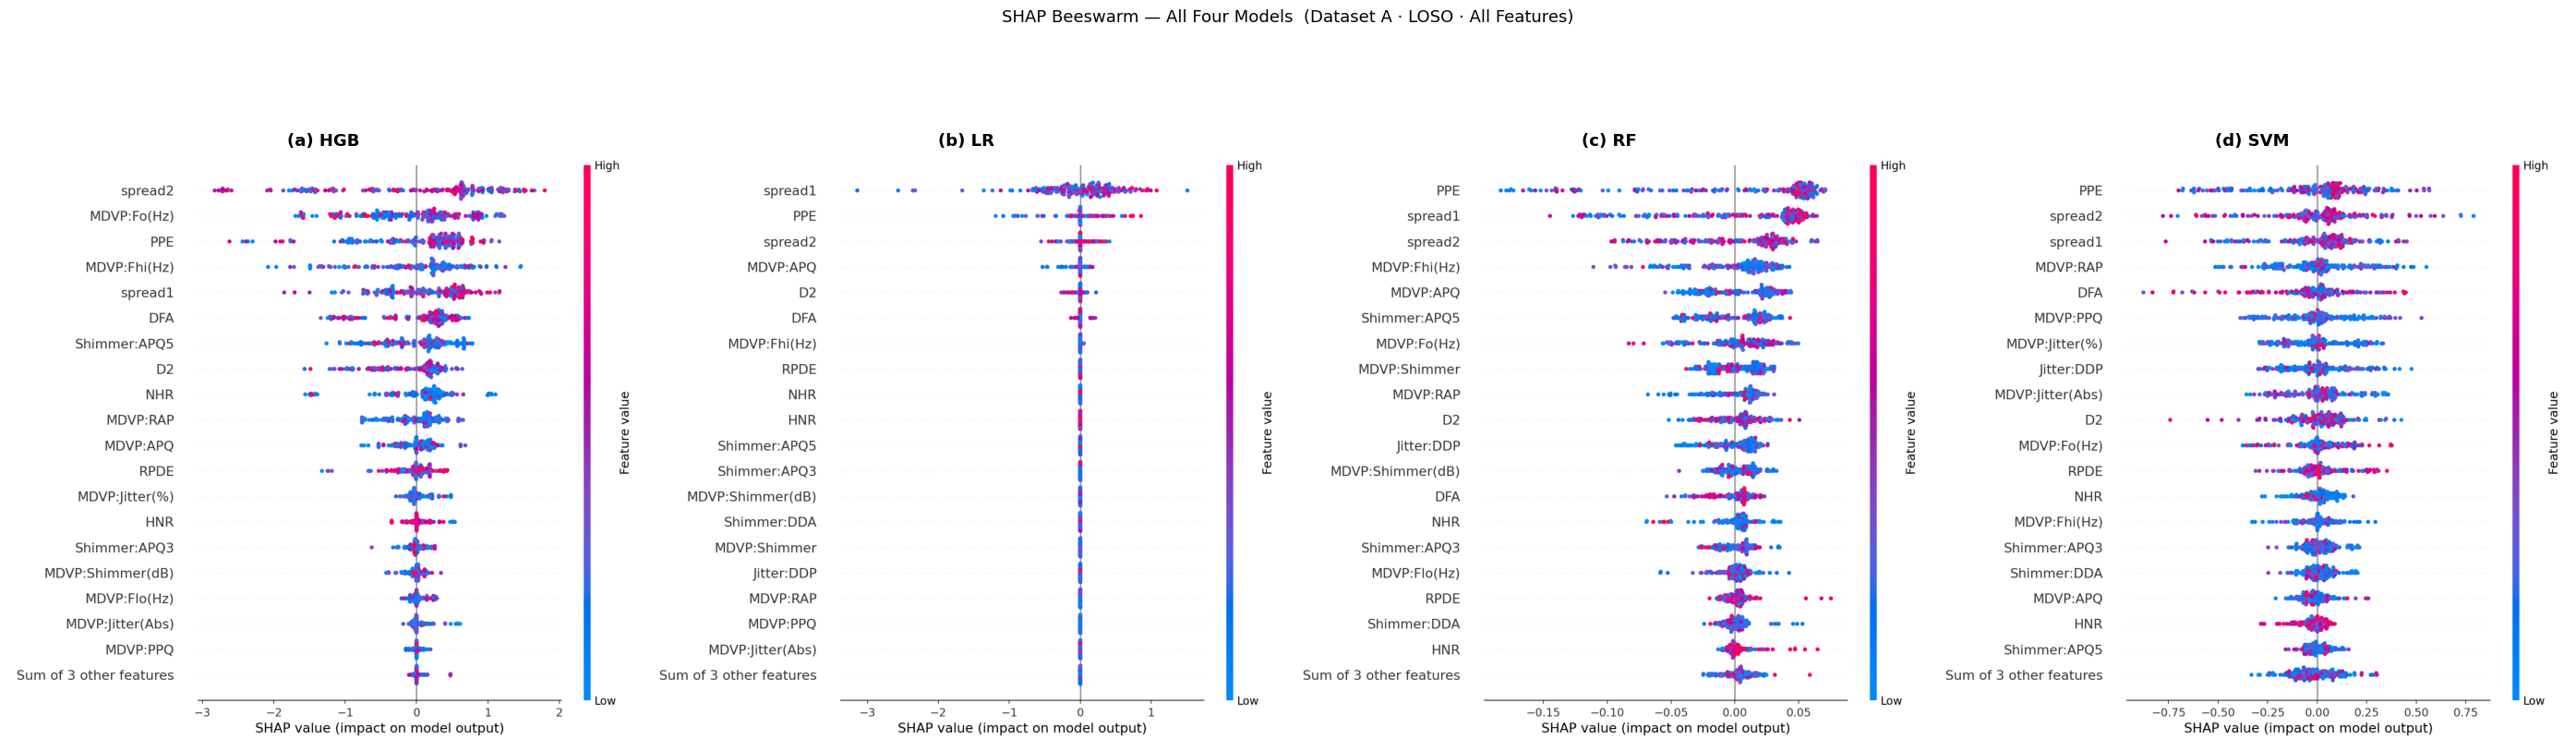

Saved -> plots/shap_4panel_beeswarm.png


In [18]:
## Combined 4-panel beeswarm (HGB / LR / RF / SVM)
from io import BytesIO
import matplotlib.image as mpimg

N_FEAT = 20

panels = [
    ("(a) HGB", hgb_exp),
    ("(b) LR",  lr_exp),
    ("(c) RF",  rf_exp),
    ("(d) SVM", svm_exp),
]

buffers = []
for label, exp in panels:
    shap.plots.beeswarm(exp, max_display=N_FEAT, show=False)
    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    buffers.append((label, mpimg.imread(buf)))
    plt.close()

fig, axes = plt.subplots(1, 4, figsize=(28, 9))
for ax, (label, img) in zip(axes, buffers):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(label, fontsize=13, fontweight="bold", pad=6)

plt.suptitle(
    "SHAP Beeswarm — All Four Models  (Dataset A · LOSO · All Features)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_4panel_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'shap_4panel_beeswarm.png'}")

## Without Outliers: LOSO SHAP (Dataset A)

In [19]:
print("Running RF LOSO SHAP on Dataset A (without outliers)…")
t0 = time.time()

rf_shap_clean, rf_X_clean, rf_y_clean, rf_yhat_clean, rf_order_clean, rf_ba_clean = loso_shap(
    make_rf_pipe, RF_GRID, X_clean_a, y_clean_a, g_clean_a, feat_cols, model_type="rf"
)

print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Mean LOSO BA: {np.mean(rf_ba_clean):.3f} ± {np.std(rf_ba_clean):.3f}")
print(f"SHAP matrix: {rf_shap_clean.shape}")
rf_importance_clean = pd.Series(np.abs(rf_shap_clean).mean(axis=0), index=feat_cols).sort_values(ascending=False)
print("\nTop 10 features by mean |SHAP|:")
print(rf_importance_clean.head(10).to_string())

Running RF LOSO SHAP on Dataset A (without outliers)…
  fold  1 (PD     ) BA=1.00 ✓  best={'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
  fold  2 (PD     ) BA=0.67 ✗  best={'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
  fold  3 (PD     ) BA=1.00 ✓  best={'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
  fold  4 (PD     ) BA=1.00 ✓  best={'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}
  fold  5 (PD     ) BA=0.83 ✓  best={'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
  fold  6 (Healthy) BA=0.00 ✗  best={'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}
  fold  7 (PD     ) BA=0.33 ✓  best={'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 200}
  fold  8 (Healthy) BA=1.00 ✓  best={'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
  fold  9 (Healthy) BA=0.00 ✗  best={'rf__max_dept

In [20]:
print("Running HGB LOSO SHAP on Dataset A (without outliers)…")
t0 = time.time()

hgb_shap_clean, hgb_X_clean, hgb_y_clean, hgb_yhat_clean, hgb_order_clean, hgb_ba_clean = loso_shap(
    make_hgb_pipe, HGB_GRID, X_clean_a, y_clean_a, g_clean_a, feat_cols, model_type="hgb"
)

print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Mean LOSO BA: {np.mean(hgb_ba_clean):.3f} ± {np.std(hgb_ba_clean):.3f}")
hgb_importance_clean = pd.Series(np.abs(hgb_shap_clean).mean(axis=0), index=feat_cols).sort_values(ascending=False)
print("\nTop 10 features by mean |SHAP|:")
print(hgb_importance_clean.head(10).to_string())

Running HGB LOSO SHAP on Dataset A (without outliers)…
  fold  1 (PD     ) BA=1.00 ✓  best={'hgb__l2_regularization': 0.1, 'hgb__learning_rate': 0.05, 'hgb__max_iter': 200, 'hgb__max_leaf_nodes': 15, 'hgb__min_samples_leaf': 10}
  fold  2 (PD     ) BA=0.83 ✓  best={'hgb__l2_regularization': 0.1, 'hgb__learning_rate': 0.1, 'hgb__max_iter': 100, 'hgb__max_leaf_nodes': 15, 'hgb__min_samples_leaf': 10}
  fold  3 (PD     ) BA=1.00 ✓  best={'hgb__l2_regularization': 0.1, 'hgb__learning_rate': 0.1, 'hgb__max_iter': 200, 'hgb__max_leaf_nodes': 5, 'hgb__min_samples_leaf': 20}
  fold  4 (PD     ) BA=1.00 ✓  best={'hgb__l2_regularization': 1.0, 'hgb__learning_rate': 0.05, 'hgb__max_iter': 100, 'hgb__max_leaf_nodes': 5, 'hgb__min_samples_leaf': 10}
  fold  5 (PD     ) BA=1.00 ✓  best={'hgb__l2_regularization': 1.0, 'hgb__learning_rate': 0.05, 'hgb__max_iter': 200, 'hgb__max_leaf_nodes': 15, 'hgb__min_samples_leaf': 10}
  fold  6 (Healthy) BA=0.17 ✗  best={'hgb__l2_regularization': 1.0, 'hgb__learn

In [21]:
print("Running LR LOSO SHAP on Dataset A (without outliers)…")
t0 = time.time()

lr_shap_clean, lr_X_clean, lr_y_clean, lr_yhat_clean, lr_order_clean, lr_ba_clean = loso_shap(
    make_lr_pipe, LR_GRID, X_clean_a, y_clean_a, g_clean_a, feat_cols, model_type="lr"
)

print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Mean LOSO BA: {np.mean(lr_ba_clean):.3f} ± {np.std(lr_ba_clean):.3f}")
lr_importance_clean = pd.Series(np.abs(lr_shap_clean).mean(axis=0), index=feat_cols).sort_values(ascending=False)
print("\nTop 10 features by mean |SHAP|:")
print(lr_importance_clean.head(10).to_string())

Running LR LOSO SHAP on Dataset A (without outliers)…
  fold  1 (PD     ) BA=1.00 ✓  best={'lr__C': np.float64(0.1)}
  fold  2 (PD     ) BA=0.83 ✓  best={'lr__C': np.float64(0.1)}
  fold  3 (PD     ) BA=0.67 ✗  best={'lr__C': np.float64(0.1)}
  fold  4 (PD     ) BA=1.00 ✓  best={'lr__C': np.float64(0.1)}
  fold  5 (PD     ) BA=0.33 ✓  best={'lr__C': np.float64(0.1)}
  fold  6 (Healthy) BA=1.00 ✓  best={'lr__C': np.float64(0.1)}
  fold  7 (PD     ) BA=0.00 ✗  best={'lr__C': np.float64(0.1)}
  fold  8 (Healthy) BA=1.00 ✓  best={'lr__C': np.float64(0.1)}
  fold  9 (Healthy) BA=0.00 ✗  best={'lr__C': np.float64(0.46415888336127775)}
  fold 10 (PD     ) BA=1.00 ✓  best={'lr__C': np.float64(0.1)}
  fold 11 (Healthy) BA=1.00 ✓  best={'lr__C': np.float64(0.1)}
  fold 12 (PD     ) BA=0.83 ✓  best={'lr__C': np.float64(2.154434690031882)}
  fold 13 (PD     ) BA=1.00 ✓  best={'lr__C': np.float64(10.0)}
  fold 14 (PD     ) BA=0.83 ✓  best={'lr__C': np.float64(0.46415888336127775)}
  fold 15 (PD    

In [22]:
print("Running SVM LOSO SHAP on Dataset A (without outliers)…")
t0 = time.time()

svm_shap_clean, svm_X_clean, svm_y_clean, svm_yhat_clean, svm_order_clean, svm_ba_clean = loso_shap(
    make_svm_pipe, SVM_GRID, X_clean_a, y_clean_a, g_clean_a, feat_cols, model_type="svm",
    inner_k=4, verbose=True,
)

print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Mean LOSO BA: {np.mean(svm_ba_clean):.3f} ± {np.std(svm_ba_clean):.3f}")
svm_importance_clean = pd.Series(np.abs(svm_shap_clean).mean(axis=0), index=feat_cols).sort_values(ascending=False)
print("\nTop 10 features by mean |SHAP|:")
print(svm_importance_clean.head(10).to_string())

Running SVM LOSO SHAP on Dataset A (without outliers)…
  fold  1 (PD     ) BA=1.00 ✓  best={'svm__C': 100, 'svm__gamma': 'scale'}
  fold  2 (PD     ) BA=0.67 ✗  best={'svm__C': 10, 'svm__gamma': 'scale'}
  fold  3 (PD     ) BA=0.33 ✗  best={'svm__C': 1, 'svm__gamma': 'scale'}
  fold  4 (PD     ) BA=1.00 ✓  best={'svm__C': 1, 'svm__gamma': 'scale'}
  fold  5 (PD     ) BA=0.83 ✓  best={'svm__C': 100, 'svm__gamma': 'scale'}
  fold  6 (Healthy) BA=0.33 ✓  best={'svm__C': 1, 'svm__gamma': 'scale'}
  fold  7 (PD     ) BA=1.00 ✓  best={'svm__C': 100, 'svm__gamma': 'scale'}
  fold  8 (Healthy) BA=1.00 ✓  best={'svm__C': 1, 'svm__gamma': 'scale'}
  fold  9 (Healthy) BA=0.00 ✗  best={'svm__C': 100, 'svm__gamma': 'scale'}
  fold 10 (PD     ) BA=1.00 ✓  best={'svm__C': 100, 'svm__gamma': 'scale'}
  fold 11 (Healthy) BA=0.83 ✗  best={'svm__C': 100, 'svm__gamma': 'scale'}
  fold 12 (PD     ) BA=1.00 ✓  best={'svm__C': 100, 'svm__gamma': 'scale'}
  fold 13 (PD     ) BA=0.60 ✗  best={'svm__C': 100, 's

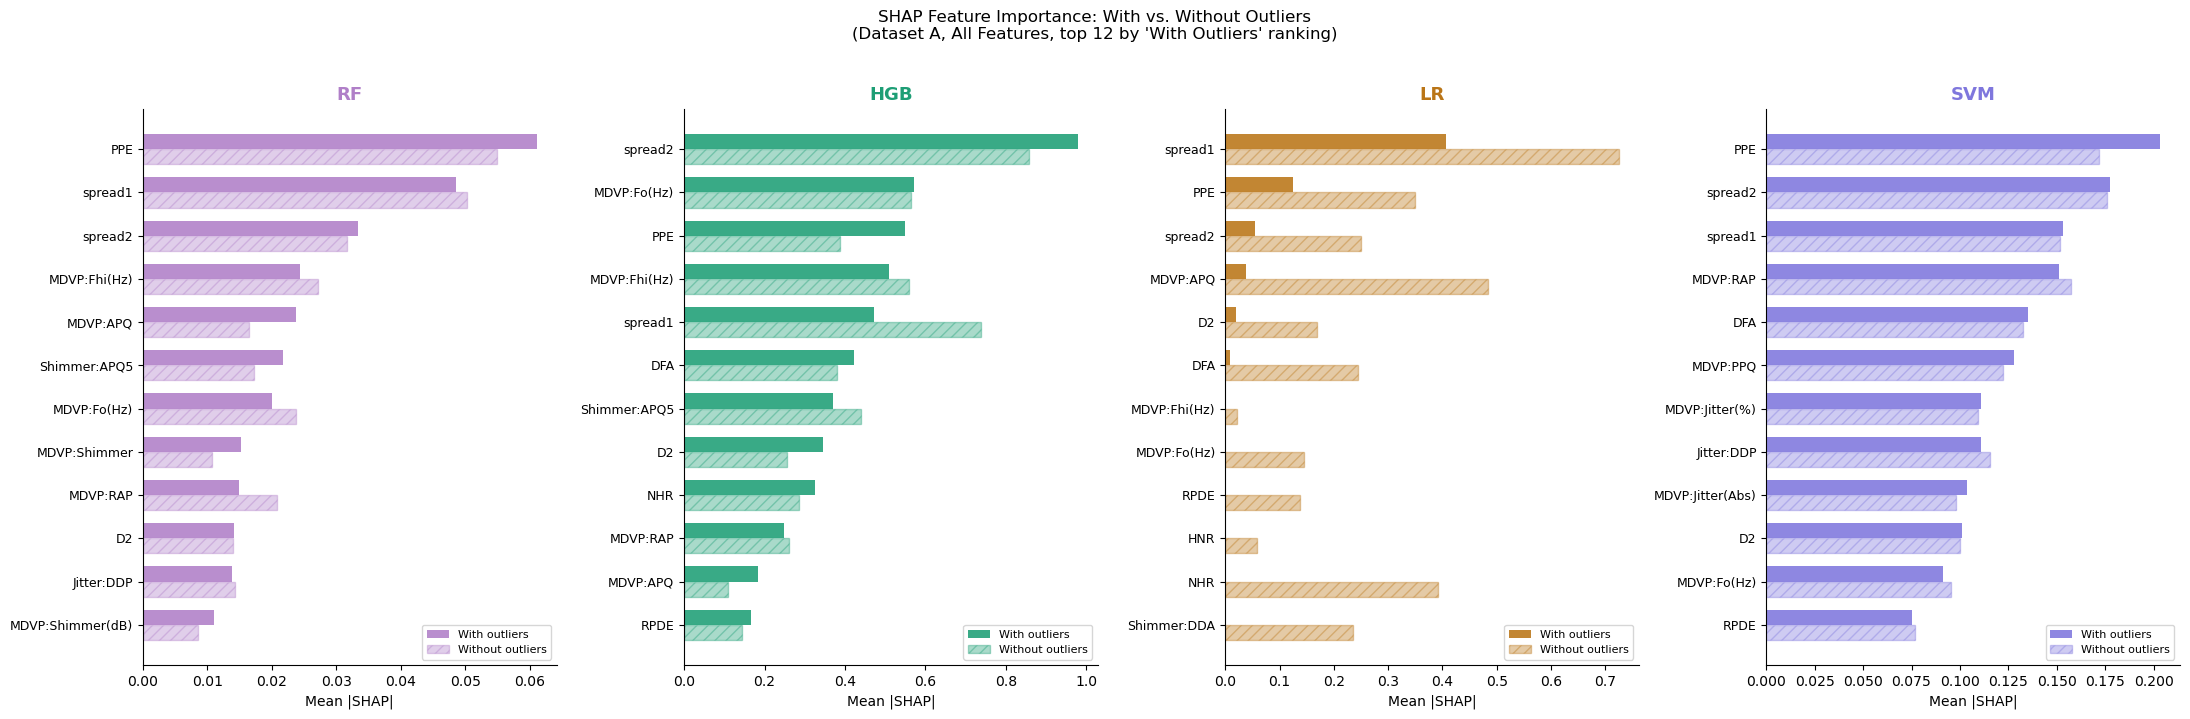

Saved -> plots/shap_outlier_impact_importance.png


In [23]:
importances_with  = {"RF": rf_importance,       "HGB": hgb_importance,       "LR": lr_importance}
importances_clean = {"RF": rf_importance_clean, "HGB": hgb_importance_clean, "LR": lr_importance_clean}
try:
    importances_with["SVM"]  = svm_importance
    importances_clean["SVM"] = svm_importance_clean
except NameError:
    pass

models_plot = list(importances_clean.keys())
N_FEAT = 12

fig, axes = plt.subplots(1, len(models_plot), figsize=(5.5 * len(models_plot), 7))
if len(models_plot) == 1:
    axes = [axes]

for ax, model in zip(axes, models_plot):
    imp_w  = importances_with[model]
    imp_wo = importances_clean[model]
    top_feats = imp_w.index.tolist()[:N_FEAT]
    y = np.arange(N_FEAT)
    bw = 0.35

    ax.barh(y + bw/2, [imp_w.get(f, 0)  for f in top_feats][::-1], bw,
            color=PALETTE[model], alpha=0.88, label="With outliers")
    ax.barh(y - bw/2, [imp_wo.get(f, 0) for f in top_feats][::-1], bw,
            color=PALETTE[model], alpha=0.38, hatch="///",
            edgecolor=PALETTE[model], label="Without outliers")

    ax.set_yticks(y)
    ax.set_yticklabels(top_feats[::-1], fontsize=9)
    ax.set_xlabel("Mean |SHAP|", fontsize=10)
    ax.set_title(model, fontsize=13, color=PALETTE[model], fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle(
    "SHAP Feature Importance: With vs. Without Outliers\n"
    "(Dataset A, All Features, top 12 by 'With Outliers' ranking)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_outlier_impact_importance.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'shap_outlier_impact_importance.png'}")

In [24]:
# Save clean SHAP matrices and importances
clean_always = [
    ("rf",  rf_shap_clean,  rf_importance_clean),
    ("hgb", hgb_shap_clean, hgb_importance_clean),
    ("lr",  lr_shap_clean,  lr_importance_clean),
]
try:
    clean_always.append(("svm", svm_shap_clean, svm_importance_clean))
except NameError:
    pass

for name, sv, imp in clean_always:
    pd.DataFrame(sv, columns=feat_cols).to_csv(OUT / f"shap_{name}_matrix_clean.csv", index=False)
    imp.reset_index().rename(columns={"index": "feature", 0: "mean_abs_shap"}).to_csv(
        OUT / f"shap_{name}_importance_clean.csv", index=False)

print("Saved clean SHAP outputs to outputs/:")
for f in sorted(OUT.glob("shap_*_clean.csv")):
    print(f"  {f.name}")

Saved clean SHAP outputs to outputs/:
  shap_hgb_importance_clean.csv
  shap_hgb_matrix_clean.csv
  shap_lr_importance_clean.csv
  shap_lr_matrix_clean.csv
  shap_rf_importance_clean.csv
  shap_rf_matrix_clean.csv
  shap_svm_importance_clean.csv
  shap_svm_matrix_clean.csv
